In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

In [7]:
df=pd.read_csv("/content/fashion_size_fit_dataset.csv")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           12000 non-null  object 
 1   user_id            12000 non-null  object 
 2   purchase_datetime  12000 non-null  object 
 3   country            12000 non-null  object 
 4   purchase_channel   12000 non-null  object 
 5   brand              12000 non-null  object 
 6   category           12000 non-null  object 
 7   subcategory        12000 non-null  object 
 8   color              12000 non-null  object 
 9   material           12000 non-null  object 
 10  base_price         12000 non-null  float64
 11  discount_pct       12000 non-null  int64  
 12  final_price        12000 non-null  float64
 13  gender             12000 non-null  object 
 14  age                12000 non-null  int64  
 15  height_cm          12000 non-null  float64
 16  weight_kg          120

In [9]:
df.head()

,order_id,user_id,purchase_datetime,country,purchase_channel,brand,category,subcategory,color,material,...,chest_bust_cm,waist_cm,hip_cm,size_system,recommended_size,purchased_size,fit_feedback,fit_score,returned,return_reason
0,ORD250809572,U43978,2024-06-01 01:53:34,India,App,Roadster,Tops,Henley,Blue,Cotton,...,101.3,82.2,94.7,Alpha,M,M,Perfect,5,0,NaN
1,ORD250804765,U33954,2025-07-06 06:49:33,UK,Web,W,Outerwear,Cardigan,Maroon,Wool,...,105.8,85.8,98.5,Alpha,M,XS,Too Small,1,1,Size too small
2,ORD250810182,U73317,2025-06-26 01:05:34,India,App,Nike,Outerwear,Blazer,Yellow,Leather,...,92.3,72.4,95.5,Alpha,S,S,Perfect,5,0,NaN
3,ORD250802447,U13991,2025-07-22 01:36:32,India,Store,Adidas,Activewear,Tank,Green,Silk,...,84.7,67.0,89.2,Alpha,XS,S,Slightly Loose,3,1,Fit was slightly loose
4,ORD250805611,U30633,2024-02-14 18:51:33,India,App,Roadster,Activewear,Track Pants,Purple,Blends,...,97.0,76.3,101.2,Alpha,S,S,Perfect,5,0,NaN


In [10]:
df.describe(include='all')

,order_id,user_id,purchase_datetime,country,purchase_channel,brand,category,subcategory,color,material,...,chest_bust_cm,waist_cm,hip_cm,size_system,recommended_size,purchased_size,fit_feedback,fit_score,returned,return_reason
count,12000,12000,12000,12000,12000,12000,12000,12000,12000,12000,...,12000.000000,12000.000000,12000.000000,12000,12000,12000,12000,12000.000000,12000.000000,8400
unique,7828,7533,7814,8,4,21,8,48,14,10,...,NaN,NaN,NaN,2,13,14,5,NaN,NaN,4
top,ORD250800656,U59025,2024-03-12 02:07:32,India,App,Biba,Bottoms,Shorts,Yellow,Leather,...,NaN,NaN,NaN,Alpha,S,XS,Perfect,NaN,NaN,Size too large
freq,12,12,12,7689,4669,607,2168,391,925,1300,...,NaN,NaN,NaN,10554,4165,3633,3600,NaN,NaN,2400
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,94.150033,75.436883,94.492892,NaN,NaN,NaN,NaN,2.680000,0.700000,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.348948,6.600181,4.669478,NaN,NaN,NaN,NaN,1.666683,0.458277,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,78.000000,60.000000,85.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,88.900000,70.300000,91.200000,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,94.000000,75.100000,94.600000,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,99.700000,80.800000,97.700000,NaN,NaN,NaN,NaN,5.000000,1.000000,NaN


In [11]:
df.isnull().sum()

,0
order_id,0
user_id,0
purchase_datetime,0
country,0
purchase_channel,0
brand,0
category,0
subcategory,0
color,0
material,0


In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df['brand'] = df['brand'].str.strip().str.title()

In [14]:
# Handle missing values
df.fillna({
    'height_cm': df['height_cm'].median(),
    'weight_kg': df['weight_kg'].median(),
    'brand': 'Unknown',
    'category': 'Unknown'
}, inplace=True)

In [17]:
# Apply string operations to categorical columns before encoding
for col in categorical_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip().str.title()

df['brand'] = df['brand'].astype(str).str.strip().str.title()
df['category'] = df['category'].astype(str).str.strip().str.title()

In [16]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [18]:
label_encoders = {}
for col in categorical_cols:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  label_encoders[col] = le

Understanding the distribution of fit_feedback (our key target variable) helps identify if the dataset is balanced or skewed. If too many samples belong to one category (e.g., Perfect Fit), the model might get biased.

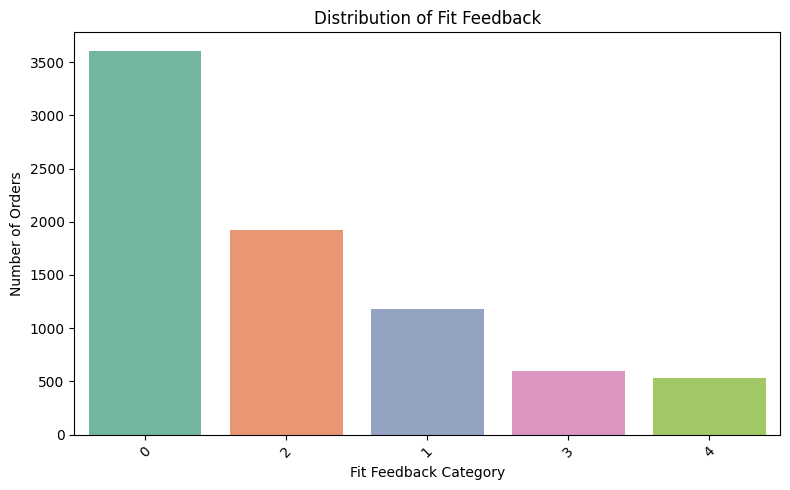

fit_feedback
0    45.988758
2    24.527338
1    15.048544
3     7.664793
4     6.770567
Name: proportion, dtype: float64


In [19]:


plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='fit_feedback', order=df['fit_feedback'].value_counts().index, palette='Set2')

plt.title('Distribution of Fit Feedback')
plt.xlabel('Fit Feedback Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Percentage breakdown
fit_dist = df['fit_feedback'].value_counts(normalize=True) * 100
print(fit_dist)


The column returned (Yes/No) reveals how often products are being returned. High return rates might correlate with wrong size recommendations, product defects, or price sensitivity.


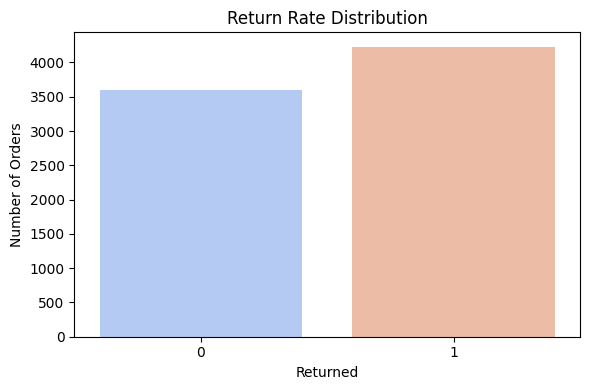

returned
1    54.011242
0    45.988758
Name: proportion, dtype: float64


In [20]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='returned', palette='coolwarm')

plt.title('Return Rate Distribution')
plt.xlabel('Returned')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

# Calculate percentage
return_rate = df['returned'].value_counts(normalize=True) * 100
print(return_rate)


Analyzing purchase_channel (e.g., Online vs Store) helps us understand the main medium for purchases. Online channels might have more returns due to size mismatch.


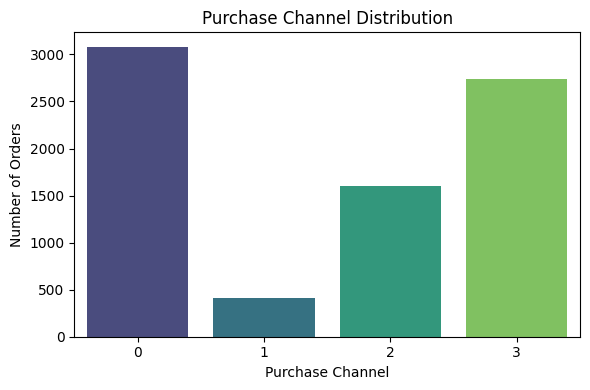

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='purchase_channel', palette='viridis')

plt.title('Purchase Channel Distribution')
plt.xlabel('Purchase Channel')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


To see if high discounts are linked with higher returns. Customers might buy impulsively on discounts and return later.

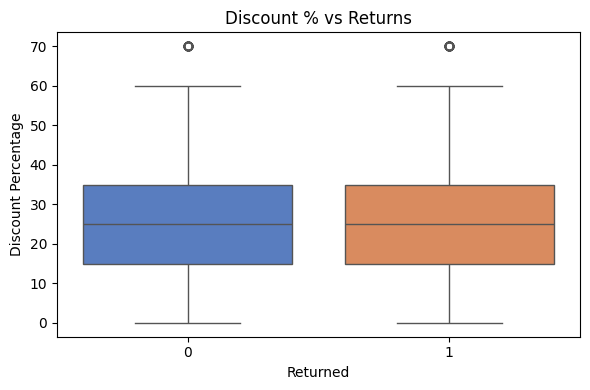

In [22]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='returned', y='discount_pct', palette='muted')

plt.title('Discount % vs Returns')
plt.xlabel('Returned')
plt.ylabel('Discount Percentage')
plt.tight_layout()
plt.show()


To see the age group of buyers. Certain age groups may be more likely to choose correct sizes or return items.

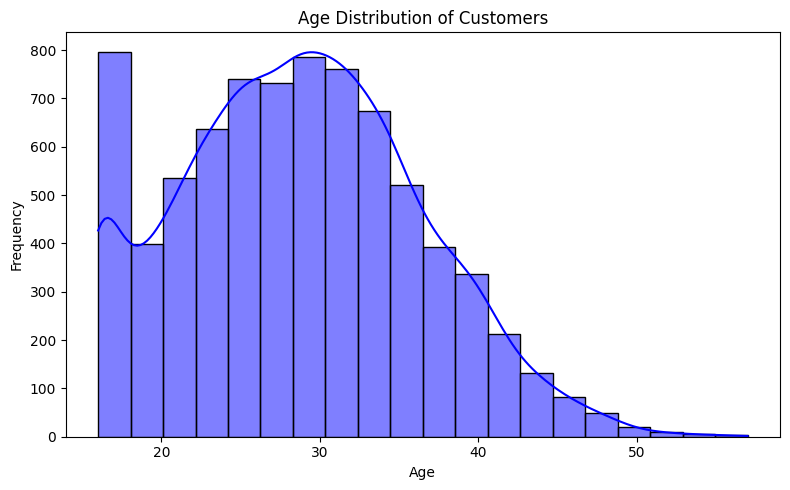

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='blue')

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


gender may impact clothing choices, return patterns, or fit feedback

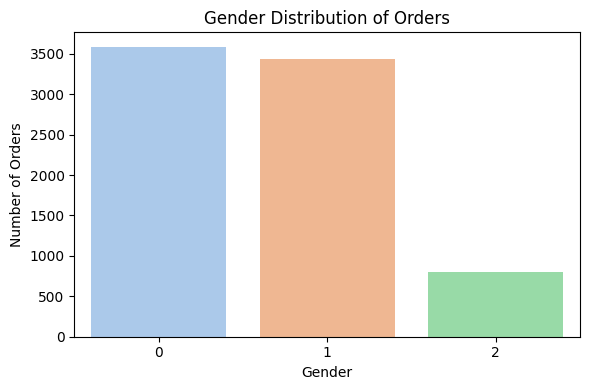

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender', palette='pastel')

plt.title('Gender Distribution of Orders')
plt.xlabel('Gender')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


Understanding which category is most sold helps identify the dominant product segment.


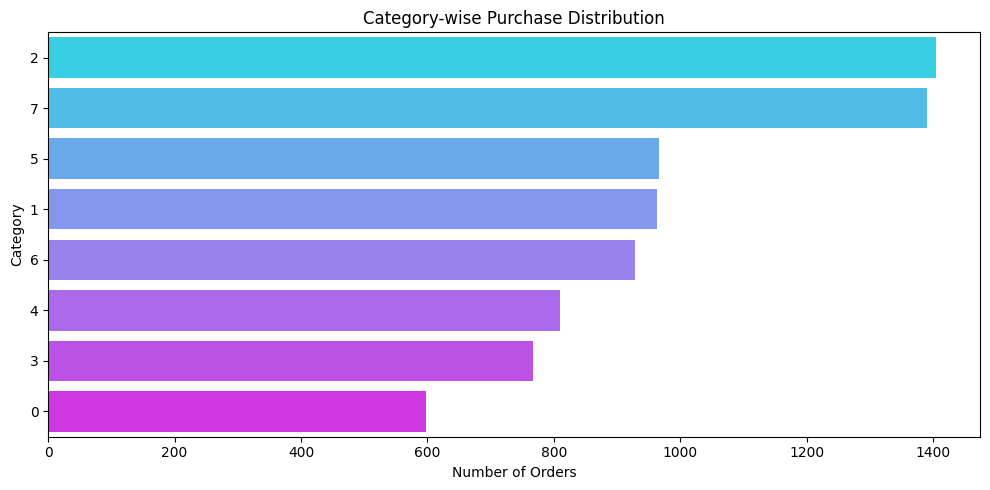

In [25]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='category', order=df['category'].value_counts().index, palette='cool')

plt.title('Category-wise Purchase Distribution')
plt.xlabel('Number of Orders')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


To detect relationships between numerical features like base_price, discount_pct, final_price, age, height_cm, weight_kg, bmi. This helps identify multicollinearity and key predictors.

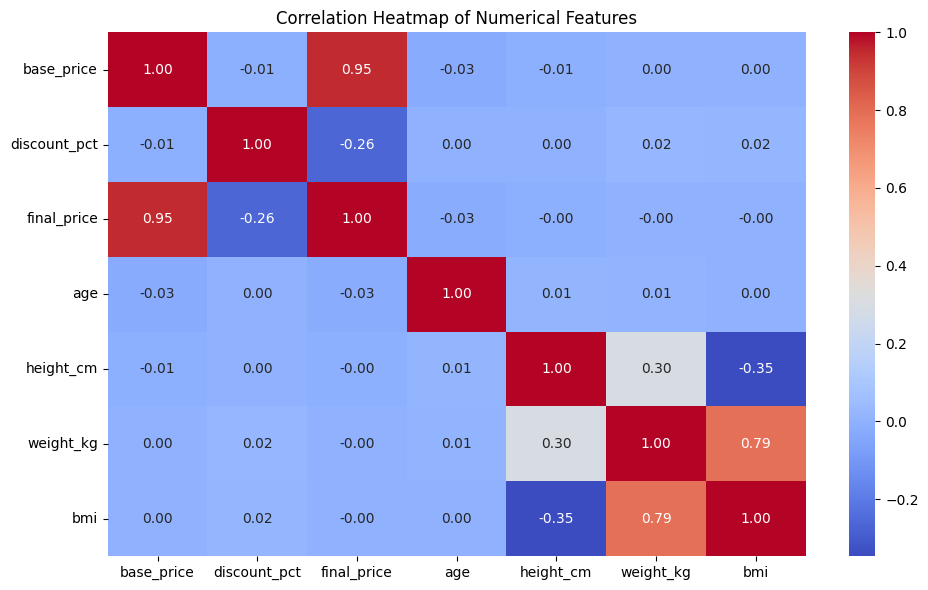

In [26]:
numerical_cols = ['base_price', 'discount_pct', 'final_price', 'age', 'height_cm', 'weight_kg', 'bmi']
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


In [27]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [28]:
# Convert 'purchase_datetime' to datetime
df['purchase_datetime'] = pd.to_datetime(df['purchase_datetime'], errors='coerce')


In [29]:
# Convert numeric columns to proper types
numeric_cols = ['base_price', 'discount_pct', 'final_price', 'age',
                'height_cm', 'weight_kg', 'bmi', 'chest_bust_cm',
                'waist_cm', 'hip_cm', 'fit_score']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Feature consistency check completed. Column names and data types are standardized.")

Feature consistency check completed. Column names and data types are standardized.


In [30]:
# Columns to check for outliers
outlier_cols = ['height_cm', 'weight_kg', 'bmi', 'base_price', 'final_price']


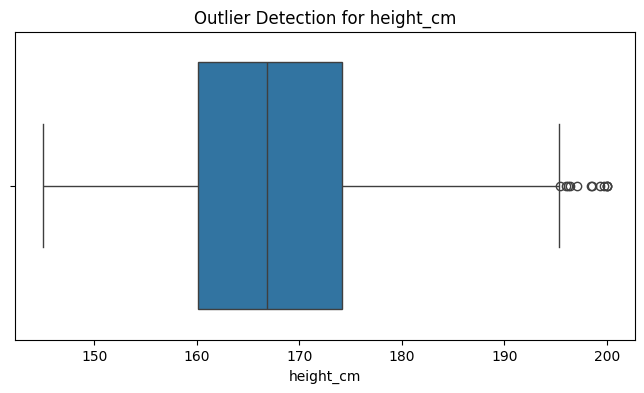

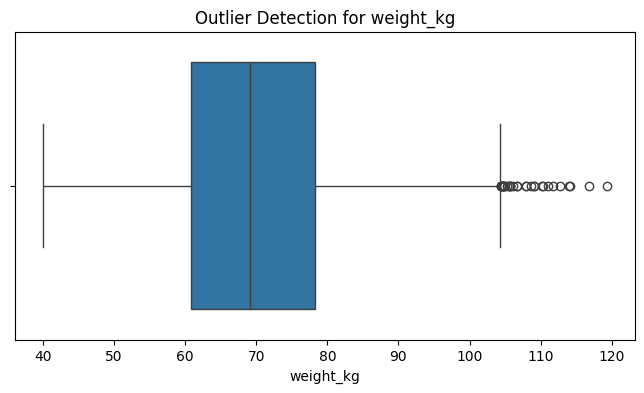

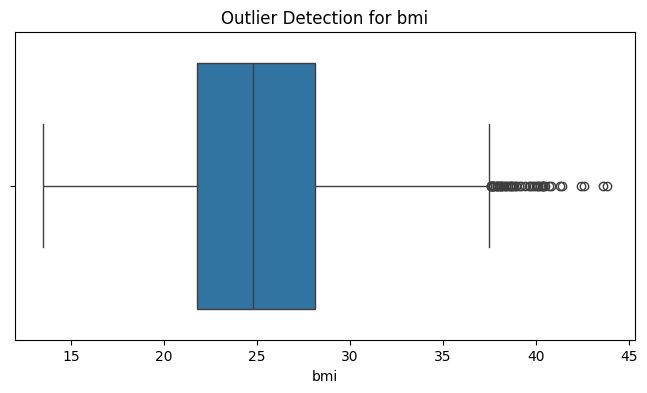

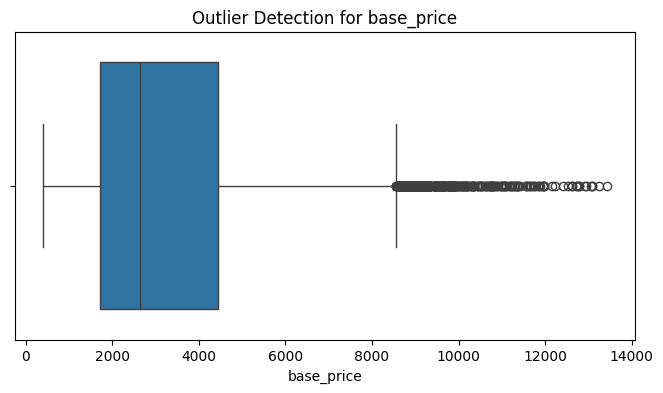

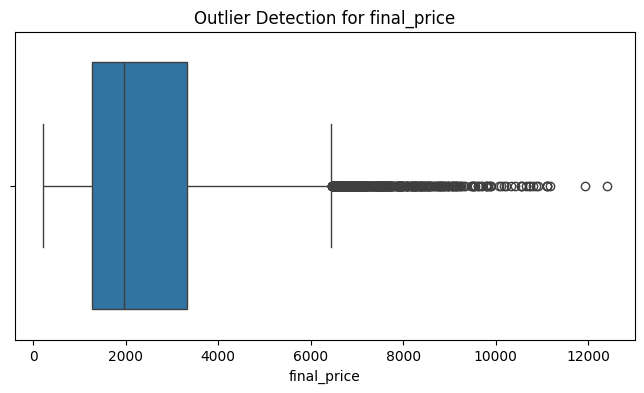

In [31]:
# Visualize outliers
for col in outlier_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection for {col}")
    plt.show()

In [32]:
# Remove outliers using IQR
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Outliers detected and removed using IQR method.")

Outliers detected and removed using IQR method.


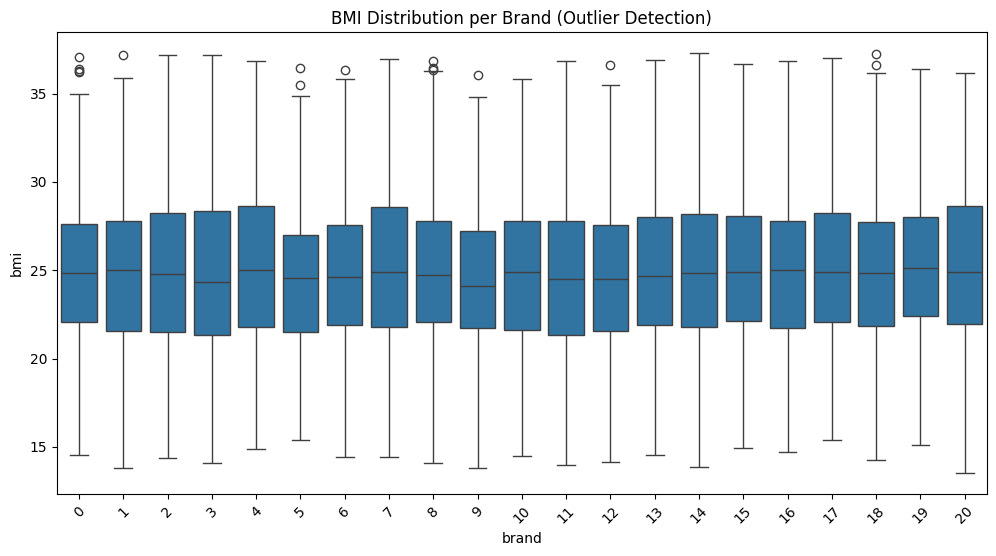

In [33]:
# Calculate BMI for reference
df['bmi'] = df['weight_kg'] / ((df['height_cm']/100) ** 2)

# Visualize outliers per brand
plt.figure(figsize=(12,6))
sns.boxplot(x='brand', y='bmi', data=df)
plt.xticks(rotation=45)
plt.title("BMI Distribution per Brand (Outlier Detection)")
plt.show()

In [36]:
fit_mapping = {
    'Too Tight': -1,
    'Perfect Fit': 0,
    'Too Loose': 1
}

df['fit_label'] = df['fit_feedback'].map(fit_mapping)


In [37]:
df.to_csv("preprocessed_data.csv", index=False)
print("Final cleaned dataset saved as 'preprocessed_data.csv'")

Final cleaned dataset saved as 'preprocessed_data.csv'
